In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [2]:
df = pd.read_csv("KNN_Social_Network_Ads.csv")

print(df.head())

print("------------")

print(df.columns)

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
------------
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [3]:
# Clean column names
df.columns = df.columns.str.strip()

# Drop unnecessary columns (if exist)
df.drop(columns = ["User ID"], errors = "ignore", inplace = True)

In [4]:
# Convert Gender (Male/Female → 1/0)
df["Gender"] = df["Gender"].map({"Male":1, "Female":0})

In [5]:
X = df.drop("Purchased", axis = 1)
y = df["Purchased"]
print(X)

     Gender  Age  EstimatedSalary
0         1   19            19000
1         1   35            20000
2         0   26            43000
3         0   27            57000
4         1   19            76000
..      ...  ...              ...
395       0   46            41000
396       1   51            23000
397       0   50            20000
398       1   36            33000
399       0   49            36000

[400 rows x 3 columns]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [9]:
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1] # Needed for ROC

C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [10]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.925


In [11]:
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Confusion Matrix :
 [[48  4]
 [ 2 26]]


In [12]:
print("Classification Report :\n", classification_report(y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score :", roc_auc)

AUC Score : 0.9532967032967034


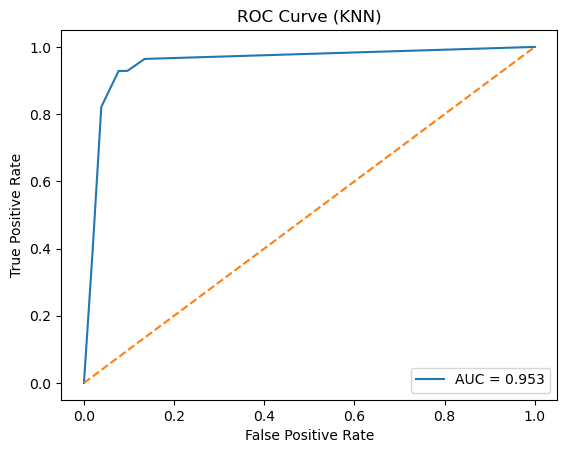

In [14]:
plt.figure()

plt.plot(fpr, tpr, label = "AUC = " + str(round(roc_auc, 3)))

# fpr → False Positive Rate
# tpr → True Positive Rate (Recall)
# label = "AUC = " + str(round(roc_auc, 3))

# 🔹 roc_auc
# Area Under Curve value (0 to 1)

# 🔹 round(roc_auc, 3)
# Rounds to 3 decimal places
# Example:
# 0.845678 → 0.846

# 🔹 Final Label:
# "AUC = 0.953"

plt.plot([0,1], [0,1], linestyle = '--') #baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (KNN)")

plt.legend()

plt.show()


In [15]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    

C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

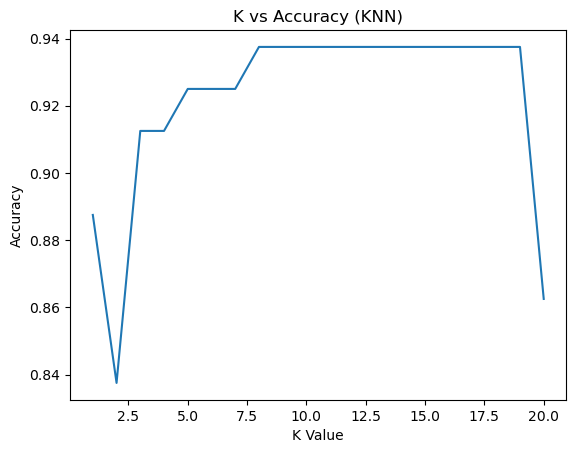

In [16]:
plt.figure()
plt.plot(k_values, accuracies)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("K vs Accuracy (KNN)")

plt.show()